# Geometric face masks

Prepared for Shivam Singh · MathTech

## Theory
A face outline can come from dense landmarks, or an approximate ellipse when no dense model is available. Refinement applies morphology and edge feathering. This is not semantic segmentation.

## Imports

In [1]:
from pathlib import Path
import sys
import numpy as np
import cv2
import matplotlib.pyplot as plt
from dataclasses import replace
from face_motion_lab.config.settings import Settings
from face_motion_lab.types import Box, Landmarks
from face_motion_lab.input.synthetic import demo_frame, SyntheticDetector
from face_motion_lab.pipeline import Pipeline
plt.rcParams.update({"figure.figsize": (9, 4), "axes.grid": True})
settings = Settings()


## Implementation

In [2]:
from face_motion_lab.segmentation.face_mask import face_mask, apply_segmentation
frame = demo_frame(30)
box = SyntheticDetector().detect(demo_frame(0))[0].bbox
mask, label = face_mask(frame, box, method="refined")
print(label)


approximate ellipse (no dense model)


## Visualization

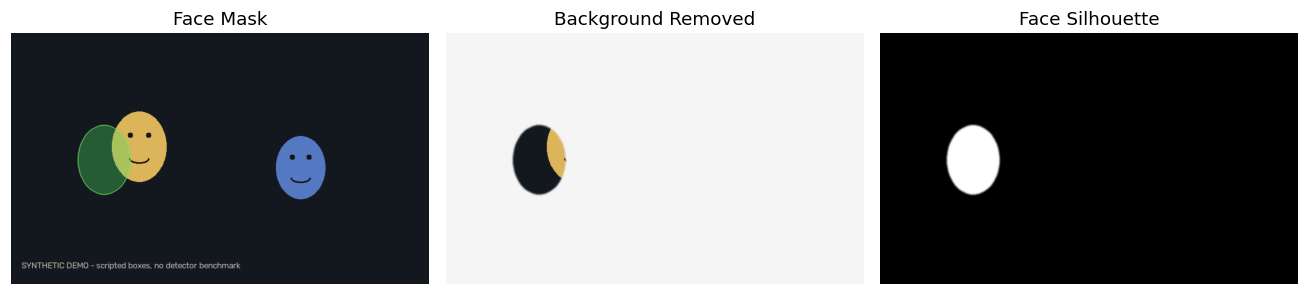

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, mode in zip(axes, ["Face Mask", "Background Removed", "Face Silhouette"]):
    output = apply_segmentation(frame.copy(), mask, replace(settings, segmentation_mode=mode, mask=True))
    ax.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB)); ax.set_title(mode); ax.axis("off")
plt.tight_layout(); plt.show()


## Experiment

In [4]:
assert mask.dtype == np.uint8 and mask.shape == frame.shape[:2]
print("Mask coverage fraction:", float(np.mean(mask > 127)))
for method in ["ellipse", "polygon", "hull", "refined", "skin"]:
    candidate, method_label = face_mask(frame, box, method=method)
    print(method, int(np.count_nonzero(candidate)), method_label)


Mask coverage fraction: 0.027440104166666666
ellipse 10539 approximate ellipse (no dense model)
polygon 10539 approximate ellipse (no dense model)
hull 10539 approximate ellipse (no dense model)
refined 11841 approximate ellipse (no dense model)
skin 0 approximate ellipse (no dense model) + heuristic skin threshold (lighting dependent)


## Observations
With no dense landmarks, polygon and hull requests correctly use the labelled ellipse fallback. Supply a real dense result to compare anatomical boundaries. A displaced box also produces a displaced mask.

## Conclusion
Mask quality depends on detection and landmark quality, not just morphology.